In [3]:
import os
import random
import time
import copy
import tarfile
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

print("Libraries imported successfully!")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Libraries imported successfully!
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [5]:
BASE_DIR = "/content/oxford_pet_project"

DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
RESULT_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Project directories created.")

Project directories created.


In [6]:
!wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz \
    -O /content/images.tar.gz

!wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz \
    -O /content/annotations.tar.gz

--2026-09-23 07:00:24--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-09-23 07:00:25--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘/content/images.tar.gz’

/content/images.tar 100%[===================>] 755.23M  26.3MB/s    in 29s     

2026-09-23 07:00:55 (25.8 MB/s) - ‘/content/images.tar.gz’ saved [791918971/791918971]

--2026-09-23 07:00:56--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.

In [7]:
print("Extracting images...")

with tarfile.open("/content/images.tar.gz", "r:gz") as tar:
    tar.extractall(DATA_DIR)

print("Images extracted.")

Extracting images...


/tmp/ipykernel_1266/3605865004.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Images extracted.


In [8]:
print("Extracting annotations...")

with tarfile.open("/content/annotations.tar.gz", "r:gz") as tar:
    tar.extractall(DATA_DIR)

print("Annotations extracted.")

Extracting annotations...


/tmp/ipykernel_1266/4086528583.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Annotations extracted.


In [9]:
print("Data directory contents:")

for item in os.listdir(DATA_DIR):
    print(item)

Data directory contents:
annotations
images


In [11]:
IMAGE_DIR = os.path.join(DATA_DIR, "images")

image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images:", len(image_files))
print("First 10 images:")

for f in image_files[:10]:
    print(f)

Total images: 7390
First 10 images:
staffordshire_bull_terrier_61.jpg
Abyssinian_21.jpg
Sphynx_45.jpg
Maine_Coon_61.jpg
chihuahua_193.jpg
beagle_72.jpg
Abyssinian_90.jpg
beagle_51.jpg
Bombay_128.jpg
Siamese_93.jpg


In [12]:
ANNOTATION_DIR = os.path.join(DATA_DIR, "annotations")

print("Annotation files:")

for item in os.listdir(ANNOTATION_DIR):
    print(item)

Annotation files:
trainval.txt
xmls
list.txt
README
trimaps
test.txt
._trimaps


In [13]:
trainval_file = os.path.join(ANNOTATION_DIR, "trainval.txt")
test_file = os.path.join(ANNOTATION_DIR, "test.txt")

trainval_df = pd.read_csv(
    trainval_file,
    sep=" ",
    header=None,
    names=["filename", "class_id", "species", "breed_id"]
)

test_df = pd.read_csv(
    test_file,
    sep=" ",
    header=None,
    names=["filename", "class_id", "species", "breed_id"]
)

print("Train/validation samples:", len(trainval_df))
print("Test samples:", len(test_df))

print("\nTrain/validation preview:")
print(trainval_df.head())

print("\nTest preview:")
print(test_df.head())

Train/validation samples: 3680
Test samples: 3669

Train/validation preview:
         filename  class_id  species  breed_id
0  Abyssinian_100         1        1         1
1  Abyssinian_101         1        1         1
2  Abyssinian_102         1        1         1
3  Abyssinian_103         1        1         1
4  Abyssinian_104         1        1         1

Test preview:
         filename  class_id  species  breed_id
0  Abyssinian_201         1        1         1
1  Abyssinian_202         1        1         1
2  Abyssinian_204         1        1         1
3  Abyssinian_205         1        1         1
4  Abyssinian_206         1        1         1


In [14]:
class_names = sorted(
    trainval_df["filename"]
    .str.rsplit("_", n=1)
    .str[0]
    .unique()
)

print("Number of classes:", len(class_names))

print("\nClasses:")

for i, name in enumerate(class_names):
    print(i, "->", name)

Number of classes: 37

Classes:
0 -> Abyssinian
1 -> Bengal
2 -> Birman
3 -> Bombay
4 -> British_Shorthair
5 -> Egyptian_Mau
6 -> Maine_Coon
7 -> Persian
8 -> Ragdoll
9 -> Russian_Blue
10 -> Siamese
11 -> Sphynx
12 -> american_bulldog
13 -> american_pit_bull_terrier
14 -> basset_hound
15 -> beagle
16 -> boxer
17 -> chihuahua
18 -> english_cocker_spaniel
19 -> english_setter
20 -> german_shorthaired
21 -> great_pyrenees
22 -> havanese
23 -> japanese_chin
24 -> keeshond
25 -> leonberger
26 -> miniature_pinscher
27 -> newfoundland
28 -> pomeranian
29 -> pug
30 -> saint_bernard
31 -> samoyed
32 -> scottish_terrier
33 -> shiba_inu
34 -> staffordshire_bull_terrier
35 -> wheaten_terrier
36 -> yorkshire_terrier


In [15]:
class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

idx_to_class = {
    idx: name
    for name, idx in class_to_idx.items()
}

print("Number of classes:", len(class_to_idx))
print("\nExample mapping:")
print(list(class_to_idx.items())[:5])

Number of classes: 37

Example mapping:
[('Abyssinian', 0), ('Bengal', 1), ('Birman', 2), ('Bombay', 3), ('British_Shorthair', 4)]


In [16]:
def get_class_name(filename):
    return filename.rsplit("_", 1)[0]


trainval_df["class_name"] = trainval_df["filename"].apply(get_class_name)
test_df["class_name"] = test_df["filename"].apply(get_class_name)

trainval_df["label"] = trainval_df["class_name"].map(class_to_idx)
test_df["label"] = test_df["class_name"].map(class_to_idx)

print(trainval_df.head())

         filename  class_id  species  breed_id  class_name  label
0  Abyssinian_100         1        1         1  Abyssinian      0
1  Abyssinian_101         1        1         1  Abyssinian      0
2  Abyssinian_102         1        1         1  Abyssinian      0
3  Abyssinian_103         1        1         1  Abyssinian      0
4  Abyssinian_104         1        1         1  Abyssinian      0


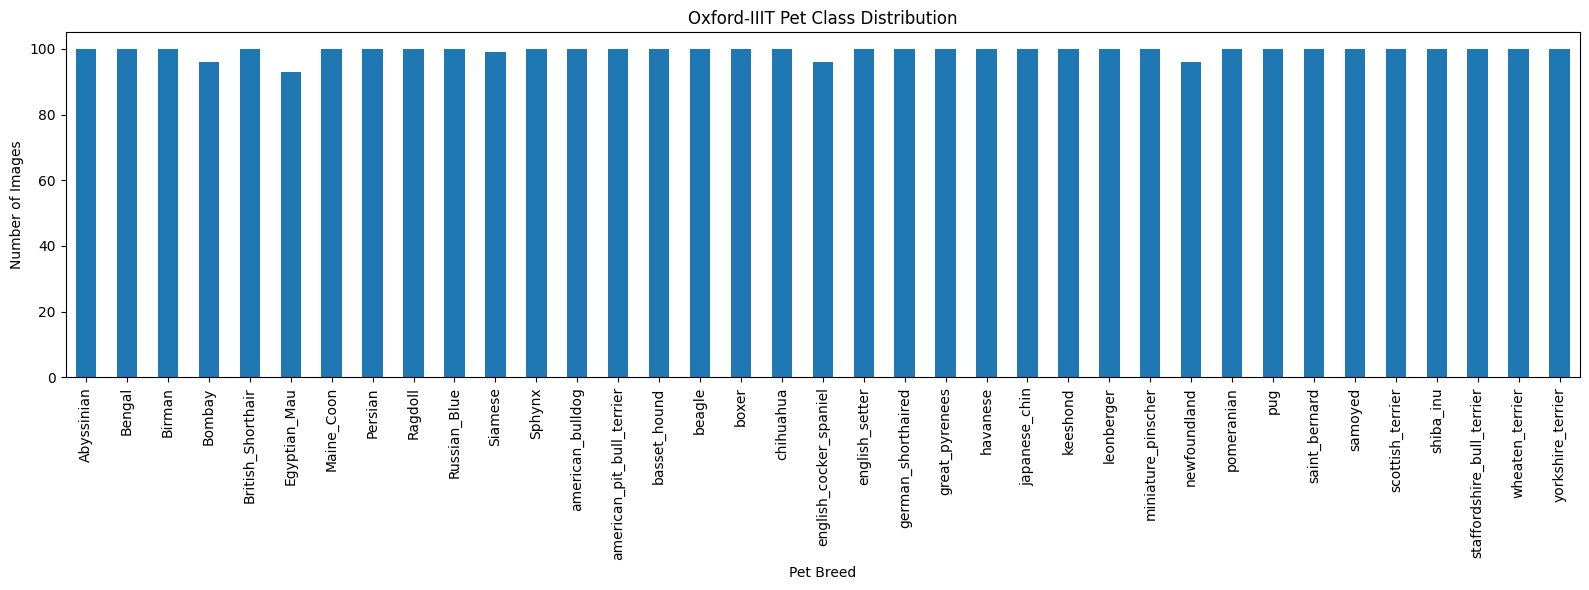

In [18]:
class_counts = trainval_df["class_name"].value_counts().sort_index()

plt.figure(figsize=(16, 6))

class_counts.plot(kind="bar")

plt.title("Oxford-IIIT Pet Class Distribution")
plt.xlabel("Pet Breed")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [19]:
print("Total images:", len(image_files))
print("Train + Validation:", len(trainval_df))
print("Test:", len(test_df))
print("Number of classes:", len(class_names))

print("\nImages per class:")
print(class_counts.describe())

Total images: 7390
Train + Validation: 3680
Test: 3669
Number of classes: 37

Images per class:
count     37.000000
mean      99.459459
std        1.556253
min       93.000000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: count, dtype: float64


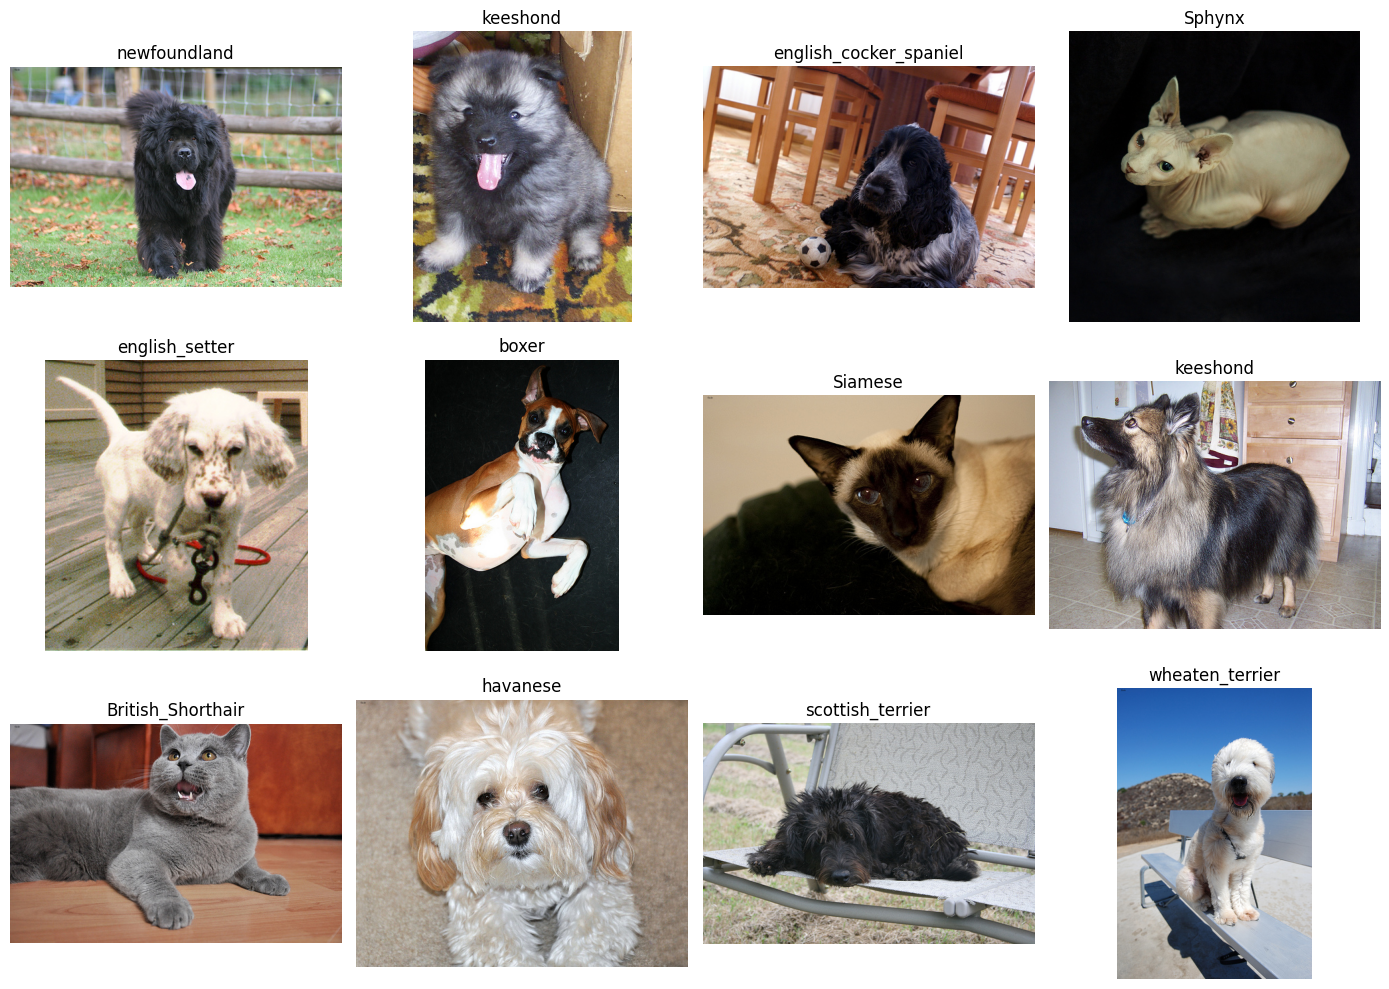

In [20]:
sample_rows = trainval_df.sample(12, random_state=42)

plt.figure(figsize=(14, 10))

for i, (_, row) in enumerate(sample_rows.iterrows()):

    image_path = os.path.join(
        IMAGE_DIR,
        row["filename"] + ".jpg"
    )

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(row["class_name"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
sample_files = random.sample(image_files, min(500, len(image_files)))

widths = []
heights = []

for filename in sample_files:

    path = os.path.join(IMAGE_DIR, filename)

    with Image.open(path) as img:
        widths.append(img.width)
        heights.append(img.height)

print("Width:")
print("Min:", min(widths))
print("Max:", max(widths))
print("Mean:", np.mean(widths))

print("\nHeight:")
print("Min:", min(heights))
print("Max:", max(heights))
print("Mean:", np.mean(heights))

Width:
Min: 198
Max: 1440
Mean: 439.776

Height:
Min: 169
Max: 2160
Mean: 393.764


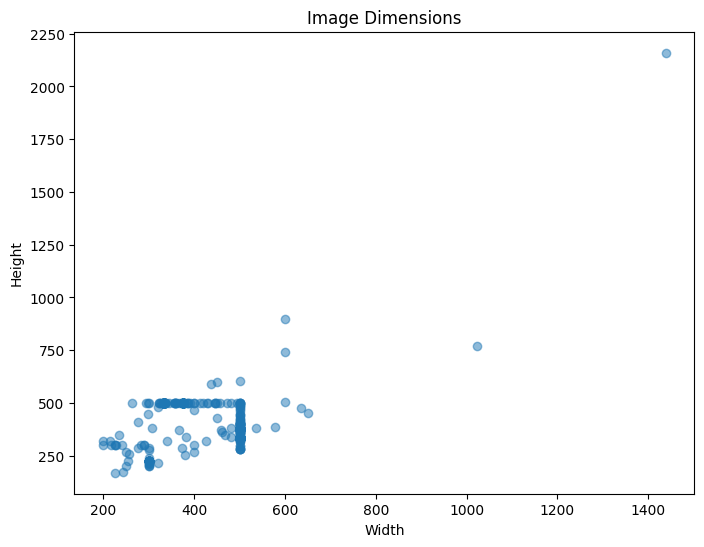

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(widths, heights, alpha=0.5)

plt.title("Image Dimensions")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

In [23]:
train_indices, val_indices = train_test_split(
    np.arange(len(trainval_df)),
    test_size=0.20,
    random_state=42,
    stratify=trainval_df["label"]
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(test_df))

Training samples: 2944
Validation samples: 736
Test samples: 3669


In [24]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.75, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [25]:
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
class OxfordPetDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = os.path.join(
            self.image_dir,
            row["filename"] + ".jpg"
        )

        image = Image.open(image_path).convert("RGB")

        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [27]:
train_df = trainval_df.iloc[train_indices].reset_index(drop=True)
val_df = trainval_df.iloc[val_indices].reset_index(drop=True)

train_dataset = OxfordPetDataset(
    train_df,
    IMAGE_DIR,
    train_transform
)

val_dataset = OxfordPetDataset(
    val_df,
    IMAGE_DIR,
    eval_transform
)

test_dataset = OxfordPetDataset(
    test_df,
    IMAGE_DIR,
    eval_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2944
Validation: 736
Test: 3669


In [28]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


In [29]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
Labels: tensor([ 0, 30, 13,  4,  9,  3, 18, 16, 35, 14])


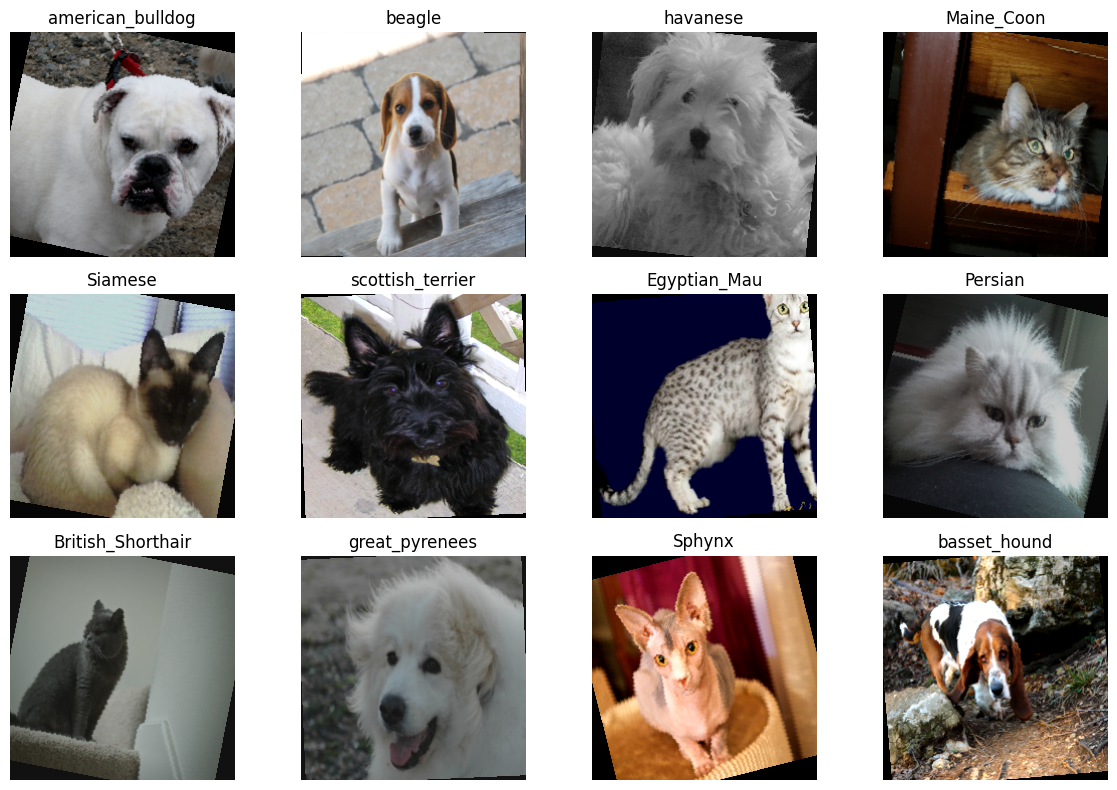

In [30]:
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(12):

    img = images[i].cpu().permute(1, 2, 0)

    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(idx_to_class[int(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
class CustomCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [32]:
custom_model = CustomCNN(
    num_classes=len(class_names)
).to(device)

print(custom_model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [33]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print(
    "Trainable parameters:",
    count_parameters(custom_model)
)

Trainable parameters: 398885


In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    custom_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Loss, optimizer and scheduler created.")

Loss, optimizer and scheduler created.


In [35]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [36]:
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [39]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("DataLoaders optimized.")

DataLoaders optimized.


In [40]:
NUM_EPOCHS = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_accuracy = 0.0
best_model_weights = copy.deepcopy(
    custom_model.state_dict()
)

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        custom_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate_model(
        custom_model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        best_model_weights = copy.deepcopy(
            custom_model.state_dict()
        )

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

training_time = time.time() - start_time

print("\nTraining completed.")
print(f"Training time: {training_time/60:.2f} minutes")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Epoch [1/15] Train Loss: 2.8239 Train Acc: 0.2211 Val Loss: 2.8614 Val Acc: 0.2024
Epoch [2/15] Train Loss: 2.7648 Train Acc: 0.2344 Val Loss: 2.8490 Val Acc: 0.2024
Epoch [3/15] Train Loss: 2.7206 Train Acc: 0.2381 Val Loss: 2.9660 Val Acc: 0.1943
Epoch [4/15] Train Loss: 2.6775 Train Acc: 0.2503 Val Loss: 2.8994 Val Acc: 0.2065
Epoch [5/15] Train Loss: 2.6719 Train Acc: 0.2452 Val Loss: 2.8542 Val Acc: 0.2269
Epoch [6/15] Train Loss: 2.6261 Train Acc: 0.2731 Val Loss: 3.0502 Val Acc: 0.1739
Epoch [7/15] Train Loss: 2.6207 Train Acc: 0.2700 Val Loss: 3.0515 Val Acc: 0.2011
Epoch [8/15] Train Loss: 2.5802 Train Acc: 0.2622 Val Loss: 2.9401 Val Acc: 0.2188
Epoch [9/15] Train Loss: 2.4976 Train Acc: 0.2884 Val Loss: 2.5301 Val Acc: 0.2799
Epoch [10/15] Train Loss: 2.4694 Train Acc: 0.3094 Val Loss: 2.7960 Val Acc: 0.2378
Epoch [11/15] Train Loss: 2.4337 Train Acc: 0.3033 Val Loss: 2.5855 Val Acc: 0.2731
Epoch [12/15] Train Loss: 2.3654 Train Acc: 0.3308 Val Loss: 2.5005 Val Acc: 0.3274
E

In [41]:
custom_model.load_state_dict(best_model_weights)

print("Best Custom CNN weights restored.")

Best Custom CNN weights restored.


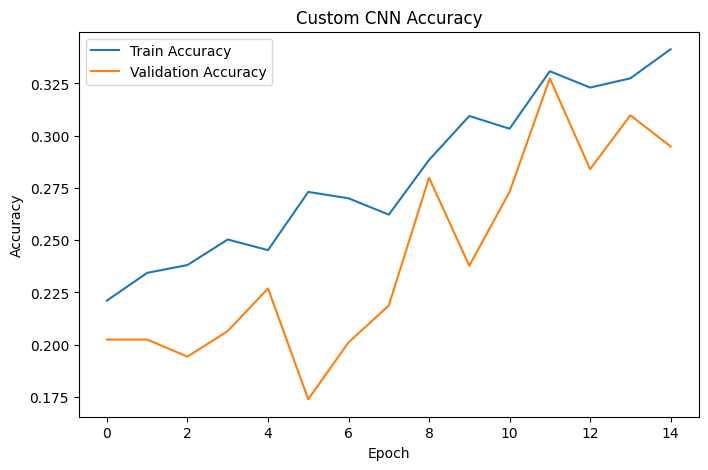

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

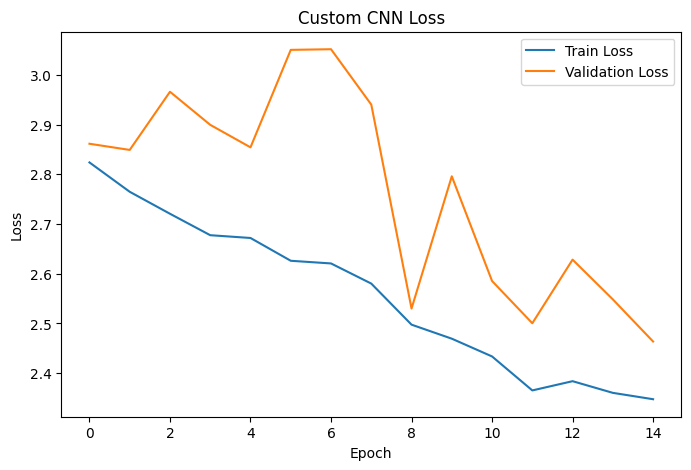

In [43]:
  plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [44]:
custom_test_loss, custom_test_accuracy = evaluate_model(
    custom_model,
    test_loader,
    criterion,
    device
)

print("Custom CNN Test Loss:", custom_test_loss)
print("Custom CNN Test Accuracy:", custom_test_accuracy)

Custom CNN Test Loss: 2.8391976912751384
Custom CNN Test Accuracy: 0.21777050967566094


In [45]:
def get_predictions(model, loader, device):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    return np.array(all_labels), np.array(all_predictions)

In [46]:
custom_y_true, custom_y_pred = get_predictions(
    custom_model,
    test_loader,
    device
)

print(
    classification_report(
        custom_y_true,
        custom_y_pred,
        target_names=class_names,
        zero_division=0
    )
)

                            precision    recall  f1-score   support

                Abyssinian       0.19      0.14      0.16        98
                    Bengal       0.38      0.52      0.44       100
                    Birman       0.22      0.33      0.27       100
                    Bombay       0.33      0.61      0.43        88
         British_Shorthair       0.27      0.13      0.18       100
              Egyptian_Mau       0.60      0.48      0.54        97
                Maine_Coon       0.20      0.11      0.14       100
                   Persian       0.28      0.22      0.24       100
                   Ragdoll       0.15      0.27      0.19       100
              Russian_Blue       0.32      0.21      0.25       100
                   Siamese       0.23      0.22      0.23       100
                    Sphynx       0.22      0.33      0.26       100
          american_bulldog       0.27      0.21      0.24       100
 american_pit_bull_terrier       0.11      0.04

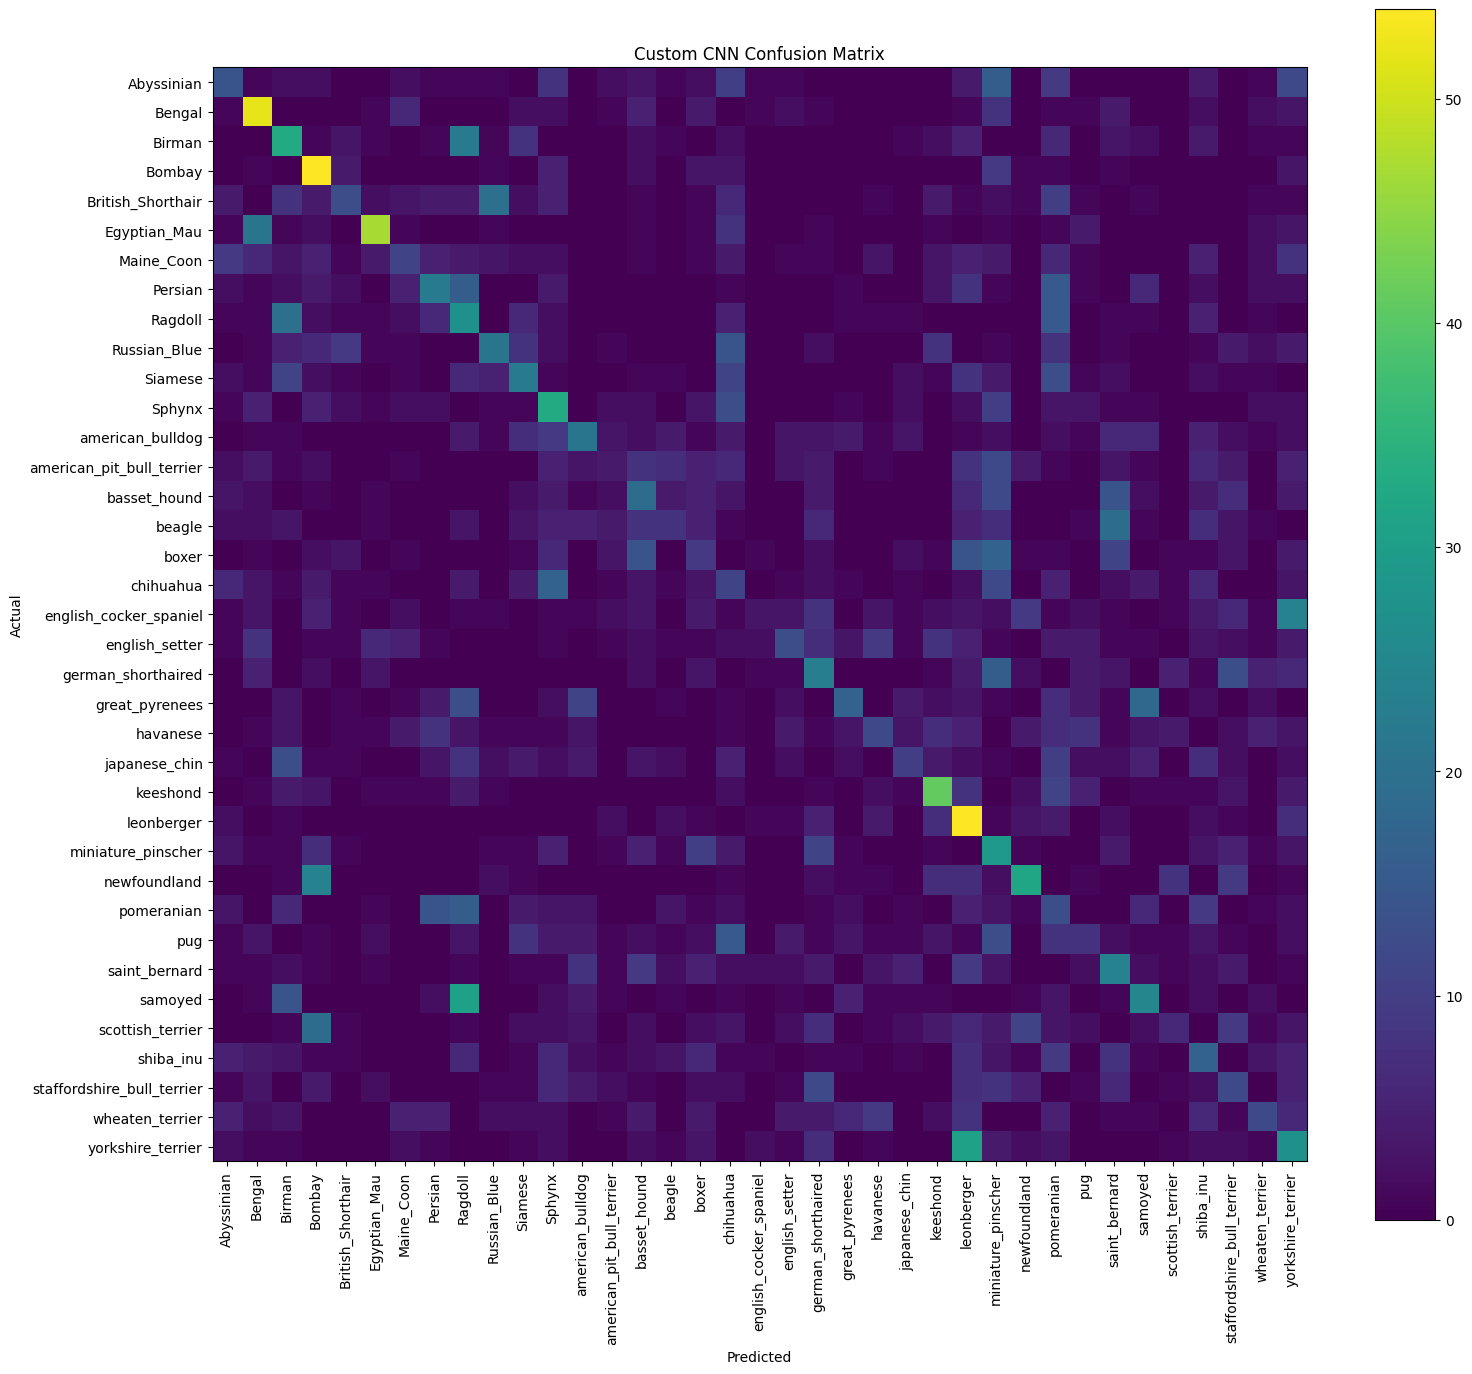

In [47]:
cm = confusion_matrix(
    custom_y_true,
    custom_y_pred
)

plt.figure(figsize=(16, 14))

plt.imshow(cm)

plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.tight_layout()
plt.show()

In [49]:
weights = models.ResNet18_Weights.DEFAULT

resnet_model = models.resnet18(
    weights=weights
)

print("Pretrained ResNet18 loaded.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 100MB/s]


Pretrained ResNet18 loaded.


In [50]:
num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Linear(
    num_features,
    len(class_names)
)

resnet_model = resnet_model.to(device)

print(resnet_model.fc)

Linear(in_features=512, out_features=37, bias=True)


In [51]:
for param in resnet_model.parameters():

    param.requires_grad = False


for param in resnet_model.fc.parameters():

    param.requires_grad = True


print(
    "Trainable parameters:",
    count_parameters(resnet_model)
)

Trainable parameters: 18981


In [52]:
criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode="max",
    factor=0.5,
    patience=2
)

print("ResNet optimizer ready.")

ResNet optimizer ready.


In [53]:
RESNET_EPOCHS = 8

resnet_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_resnet_accuracy = 0.0
best_resnet_weights = copy.deepcopy(
    resnet_model.state_dict()
)

start_time = time.time()

for epoch in range(RESNET_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        resnet_model,
        train_loader,
        criterion_resnet,
        optimizer_resnet,
        device
    )

    val_loss, val_acc = evaluate_model(
        resnet_model,
        val_loader,
        criterion_resnet,
        device
    )

    scheduler_resnet.step(val_acc)

    resnet_history["train_loss"].append(train_loss)
    resnet_history["train_acc"].append(train_acc)

    resnet_history["val_loss"].append(val_loss)
    resnet_history["val_acc"].append(val_acc)

    if val_acc > best_resnet_accuracy:

        best_resnet_accuracy = val_acc

        best_resnet_weights = copy.deepcopy(
            resnet_model.state_dict()
        )

    print(
        f"Epoch [{epoch+1}/{RESNET_EPOCHS}] "
        f"Train Acc: {train_acc:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

print(
    f"\nFeature extraction training time: "
    f"{(time.time()-start_time)/60:.2f} minutes"
)

print(
    "Best validation accuracy:",
    best_resnet_accuracy
)

Epoch [1/8] Train Acc: 0.4032 Val Acc: 0.6943
Epoch [2/8] Train Acc: 0.7768 Val Acc: 0.8071
Epoch [3/8] Train Acc: 0.8376 Val Acc: 0.8505
Epoch [4/8] Train Acc: 0.8679 Val Acc: 0.8614
Epoch [5/8] Train Acc: 0.8808 Val Acc: 0.8478
Epoch [6/8] Train Acc: 0.8927 Val Acc: 0.8682
Epoch [7/8] Train Acc: 0.9012 Val Acc: 0.8750
Epoch [8/8] Train Acc: 0.9107 Val Acc: 0.8682

Feature extraction training time: 3.41 minutes
Best validation accuracy: 0.875


In [54]:
resnet_model.load_state_dict(
    best_resnet_weights
)

print("Best ResNet weights restored.")

Best ResNet weights restored.


In [55]:
feature_test_loss, feature_test_accuracy = evaluate_model(
    resnet_model,
    test_loader,
    criterion_resnet,
    device
)

print(
    "ResNet Feature Extractor Test Accuracy:",
    feature_test_accuracy
)

ResNet Feature Extractor Test Accuracy: 0.8364677023712184


In [56]:
for param in resnet_model.layer4.parameters():

    param.requires_grad = True

for param in resnet_model.fc.parameters():

    param.requires_grad = True

print(
    "Trainable parameters after fine-tuning:",
    count_parameters(resnet_model)
)

Trainable parameters after fine-tuning: 8412709


In [57]:
optimizer_finetune = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        resnet_model.parameters()
    ),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler_finetune = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_finetune,
    mode="max",
    factor=0.5,
    patience=2
)

print("Fine-tuning optimizer ready.")

Fine-tuning optimizer ready.


In [58]:
FINETUNE_EPOCHS = 10

finetune_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_finetune_accuracy = 0.0
best_finetune_weights = copy.deepcopy(
    resnet_model.state_dict()
)

start_time = time.time()

for epoch in range(FINETUNE_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        resnet_model,
        train_loader,
        criterion_resnet,
        optimizer_finetune,
        device
    )

    val_loss, val_acc = evaluate_model(
        resnet_model,
        val_loader,
        criterion_resnet,
        device
    )

    scheduler_finetune.step(val_acc)

    finetune_history["train_loss"].append(train_loss)
    finetune_history["train_acc"].append(train_acc)

    finetune_history["val_loss"].append(val_loss)
    finetune_history["val_acc"].append(val_acc)

    if val_acc > best_finetune_accuracy:

        best_finetune_accuracy = val_acc

        best_finetune_weights = copy.deepcopy(
            resnet_model.state_dict()
        )

    print(
        f"Epoch [{epoch+1}/{FINETUNE_EPOCHS}] "
        f"Train Acc: {train_acc:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

print(
    f"\nFine-tuning time: "
    f"{(time.time()-start_time)/60:.2f} minutes"
)

print(
    "Best fine-tuning validation accuracy:",
    best_finetune_accuracy
)

Epoch [1/10] Train Acc: 0.9049 Val Acc: 0.8940
Epoch [2/10] Train Acc: 0.9545 Val Acc: 0.8804
Epoch [3/10] Train Acc: 0.9728 Val Acc: 0.9062
Epoch [4/10] Train Acc: 0.9878 Val Acc: 0.9062
Epoch [5/10] Train Acc: 0.9905 Val Acc: 0.9049
Epoch [6/10] Train Acc: 0.9942 Val Acc: 0.9117
Epoch [7/10] Train Acc: 0.9942 Val Acc: 0.9076
Epoch [8/10] Train Acc: 0.9976 Val Acc: 0.9117
Epoch [9/10] Train Acc: 0.9969 Val Acc: 0.8967
Epoch [10/10] Train Acc: 0.9986 Val Acc: 0.9076

Fine-tuning time: 4.32 minutes
Best fine-tuning validation accuracy: 0.9116847826086957


In [59]:
resnet_model.load_state_dict(
    best_finetune_weights
)

print("Best fine-tuned model restored.")

Best fine-tuned model restored.


In [60]:
final_test_loss, final_test_accuracy = evaluate_model(
    resnet_model,
    test_loader,
    criterion_resnet,
    device
)

print("Final Test Loss:", final_test_loss)
print("Final Test Accuracy:", final_test_accuracy)

Final Test Loss: 0.4117180961383465
Final Test Accuracy: 0.8727173616789315


In [61]:
final_y_true, final_y_pred = get_predictions(
    resnet_model,
    test_loader,
    device
)

report = classification_report(
    final_y_true,
    final_y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                            precision    recall  f1-score   support

                Abyssinian       0.82      0.79      0.80        98
                    Bengal       0.78      0.92      0.84       100
                    Birman       0.75      0.77      0.76       100
                    Bombay       0.90      0.91      0.90        88
         British_Shorthair       0.88      0.84      0.86       100
              Egyptian_Mau       0.93      0.88      0.90        97
                Maine_Coon       0.75      0.83      0.79       100
                   Persian       0.89      0.75      0.82       100
                   Ragdoll       0.74      0.62      0.67       100
              Russian_Blue       0.85      0.86      0.86       100
                   Siamese       0.85      0.88      0.86       100
                    Sphynx       0.87      0.97      0.92       100
          american_bulldog       0.65      0.88      0.75       100
 american_pit_bull_terrier       0.79      0.46

In [62]:
precision, recall, f1, _ = precision_recall_fscore_support(
    final_y_true,
    final_y_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy :", accuracy_score(final_y_true, final_y_pred))
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8727173616789315
Precision: 0.8755051196937041
Recall   : 0.8727173616789315
F1 Score : 0.8709854158741357


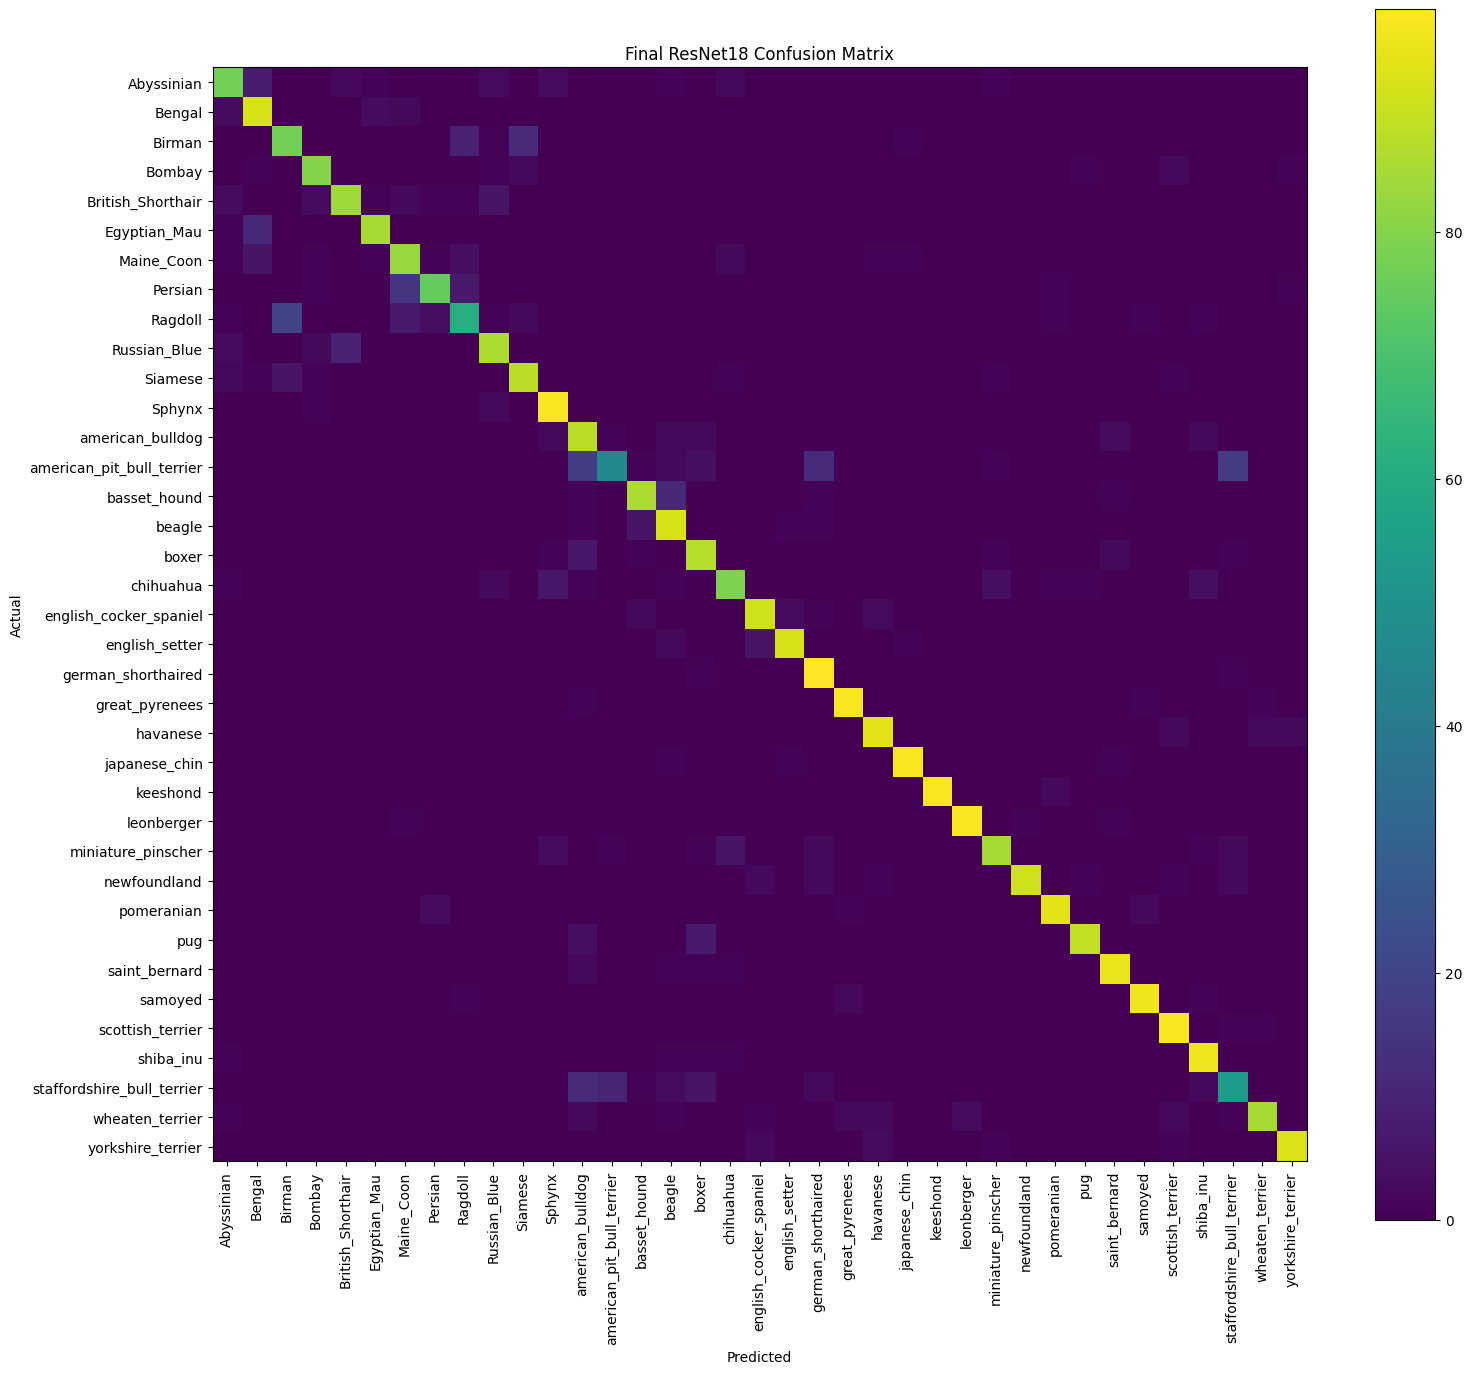

In [63]:
cm_final = confusion_matrix(
    final_y_true,
    final_y_pred
)

plt.figure(figsize=(16, 14))

plt.imshow(cm_final)

plt.title("Final ResNet18 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.tight_layout()
plt.show()

In [64]:
comparison = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet18 Feature Extractor",
        "ResNet18 Fine-Tuned"
    ],
    "Test Accuracy": [
        custom_test_accuracy,
        feature_test_accuracy,
        final_test_accuracy
    ]
})

comparison

,Model,Test Accuracy
0,Custom CNN,0.217771
1,ResNet18 Feature Extractor,0.836468
2,ResNet18 Fine-Tuned,0.872717


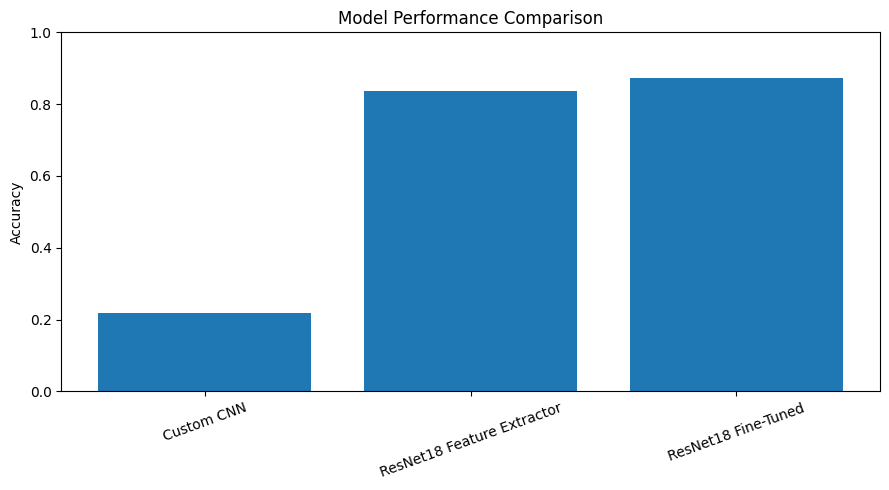

In [65]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")

plt.xticks(rotation=20)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [66]:
model_path = os.path.join(
    MODEL_DIR,
    "oxford_pet_resnet18_finetuned.pth"
)

checkpoint = {
    "model_state_dict": resnet_model.state_dict(),
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "image_size": IMAGE_SIZE,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225]
}

torch.save(
    checkpoint,
    model_path
)

print("Model saved to:")
print(model_path)

Model saved to:
/content/oxford_pet_project/models/oxford_pet_resnet18_finetuned.pth


In [67]:
print(
    "Model file exists:",
    os.path.exists(model_path)
)

if os.path.exists(model_path):

    size_mb = os.path.getsize(model_path) / (1024 ** 2)

    print(
        f"Model size: {size_mb:.2f} MB"
    )

Model file exists: True
Model size: 42.79 MB


In [68]:
  def predict_image(
    image_path,
    model,
    class_names,
    transform,
    device,
    top_k=5
):

    model.eval()

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = transform(image)

    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    with torch.no_grad():

        outputs = model(image_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        top_probs, top_indices = torch.topk(
            probabilities,
            top_k
        )

    top_probs = top_probs.cpu().numpy()[0]
    top_indices = top_indices.cpu().numpy()[0]

    results = []

    for probability, index in zip(
        top_probs,
        top_indices
    ):

        results.append({
            "class": class_names[index],
            "probability": float(probability)
        })

    return results

In [75]:
from google.colab import files

uploaded = files.upload()

uploaded_filename = list(uploaded.keys())[0]

print("Uploaded:", uploaded_filename)

Saving Pomeranian-dog.webp to Pomeranian-dog.webp
Uploaded: Pomeranian-dog.webp


In [76]:
results = predict_image(
    uploaded_filename,
    resnet_model,
    class_names,
    eval_transform,
    device,
    top_k=5
)

print("Top predictions:\n")

for result in results:

    print(
        f"{result['class']}: "
        f"{result['probability']*100:.2f}%"
    )

Top predictions:

pomeranian: 62.06%
samoyed: 23.47%
japanese_chin: 4.85%
Persian: 3.87%
Birman: 2.79%


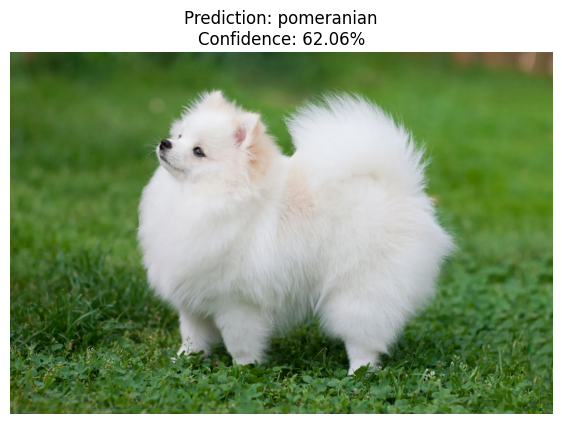

In [77]:
image = Image.open(
    uploaded_filename
).convert("RGB")

plt.figure(figsize=(7, 7))

plt.imshow(image)

plt.title(
    f"Prediction: {results[0]['class']}\n"
    f"Confidence: {results[0]['probability']*100:.2f}%"
)

plt.axis("off")

plt.show()

In [78]:
!pip install -q gradio

In [79]:
import gradio as gr


def gui_predict(image):

    image = image.convert("RGB")

    image_tensor = eval_transform(image)

    image_tensor = image_tensor.unsqueeze(0).to(device)

    resnet_model.eval()

    with torch.no_grad():

        outputs = resnet_model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[0]

    top_probs, top_indices = torch.topk(
        probabilities,
        5
    )

    results = {}

    for probability, index in zip(
        top_probs.cpu().numpy(),
        top_indices.cpu().numpy()
    ):

        results[
            class_names[index]
        ] = float(probability)

    return results

In [80]:
demo = gr.Interface(
    fn=gui_predict,
    inputs=gr.Image(
        type="pil",
        label="Upload Pet Image"
    ),
    outputs=gr.Label(
        num_top_classes=5,
        label="Predictions"
    ),
    title="Oxford-IIIT Pet Breed Classifier",
    description=(
        "Upload an image of a cat or dog "
        "and the fine-tuned ResNet18 model "
        "will predict the breed."
    )
)

demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9660516f472d57c90f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [81]:
experiment_results = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "ResNet18 Feature Extraction",
        "ResNet18 Fine-Tuning"
    ],

    "Test Accuracy": [
        custom_test_accuracy,
        feature_test_accuracy,
        final_test_accuracy
    ],

    "Validation Accuracy": [
        best_val_accuracy,
        best_resnet_accuracy,
        best_finetune_accuracy
    ]
})

results_path = os.path.join(
    RESULT_DIR,
    "model_comparison.csv"
)

experiment_results.to_csv(
    results_path,
    index=False
)

print(experiment_results)
print("\nSaved to:", results_path)

                         Model  Test Accuracy  Validation Accuracy
0                   Custom CNN       0.217771             0.327446
1  ResNet18 Feature Extraction       0.836468             0.875000
2         ResNet18 Fine-Tuning       0.872717             0.911685

Saved to: /content/oxford_pet_project/results/model_comparison.csv


In [82]:
class_names_path = os.path.join(
    MODEL_DIR,
    "class_names.json"
)

with open(
    class_names_path,
    "w"
) as f:

    json.dump(
        class_names,
        f,
        indent=4
    )

print(
    "Class names saved to:",
    class_names_path
)

Class names saved to: /content/oxford_pet_project/models/class_names.json
